<table style="width: 100%">
    <tr style="background: #ffffff">
        <td style="padding-top:25px;width: 180px"><img src="https://mci.edu/templates/mci/images/logo.svg" alt="Logo"></td>
        <td style="width: 100%">
            <div style="text-align:right; width: 100%; text-align:right"><font style="font-size:38px"><b>Programmierübung I</b></font></div>
            <div style="padding-top:0px; width: 100%; text-align:right"><font size="4"><b>WS 2024</b></font></div>
        </td>
    </tr>
</table>

---

# pandas, Datenverarbeitung und -analyse
----

Gelegentlich kommt es vor, dass wir Daten verarbeiten wollen, die nicht rein numerisch sind. Hierfür ist die Bibliothek pandas von Vorteil. (https://pandas.pydata.org/). Der Name leitet sich von "panel data" ab. 

pandas ist eine Open-Source-Bibliothek, die für Datenmanipulation und -analyse in Python entwickelt wurde. Sie bietet Datenstrukturen und -funktionen, die es erleichtern, mit strukturierten Daten, insbesondere tabellarischen Daten, umzugehen. In der Medizintechnik sind potentielle Anwendungsfälle im Patientendatenmanagement, in der statistischen Analyse von klinischen Studien. Im Sport lassen sich beispielsweise Trainings- und Leistungsdaten analysieren.

Im ersten Schritt importieren wir pandas und numpy:

In [1]:
import pandas as pd
import numpy as np

Damit haben wir pandas eingebunden. Die folgenden Ausführungen sind angelehnt an die Dokumentation (https://pandas.pydata.org/docs/user_guide/10min.html).

# 2. Series

pandas arbeitet hauptsächlich mit zwei Arten von Datenstrukturen: Series und DataFrames.

Eine Series ist eine eindimensionale Datenstruktur in pandas. Sie kann beispielsweise über eine Liste erstellt werden. Die Eingabewerte und Daten einer Series können verschiedene Datentypen haben, einschließlich numerischer Werte, Strings, Datum/Zeit-Objekte oder sogar andere komplexe Datenstrukturen.

In [2]:
# Hier wird die Series erstellt.
s = pd.Series([1, 3, 5, np.nan, 6, 8])
print(s)

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64


Jede Series hat einen Index, der die Labels für die Datenpunkte in der Reihe darstellt. Der Index kann explizit angegeben werden, andernfalls wird ein standardmäßiger ganzzahliger Index erstellt.

In [3]:
# Hier wird s mit dem Index 2 ausgegeben.
print(s[2])

5.0


Der Zugriff auf Elemente in einer Series kann auch durch Verwendung von Labels erfolgen. Das bedeutet, dass auf Datenpunkte mithilfe des Schlüssels zugegriffen werden kann.

In [4]:
# Hier wird eine Series aus einem dictionary erstellt
data = {'A': 10, 'B': 20, 'C': 30}
series = pd.Series(data)

print(series)

A    10
B    20
C    30
dtype: int64


In [5]:
# und mithilfe des Index darauf zugegriffen.
print(series['B'])
print(series[1])

20
20


Der Series kann auch ein Name zugewiesen werden.

In [6]:
series = pd.Series([1, 2, 3], name='MySeries')
print(series)

0    1
1    2
2    3
Name: MySeries, dtype: int64


Wie numpy-Arrays unterstützen auch Series vektorisierte Operationen, was bedeutet, dass  Operationen auf der gesamten Reihe durchgeführt werden können, ohne explizite Schleifen zu verwenden.

In [7]:
# Hier wird die Series vektorisiert multipliziert
doubled_series = series * 2
print(doubled_series)

0    2
1    4
2    6
Name: MySeries, dtype: int64


Beim vektorisierten Zusammenrechnen zweier Series wird dies an den Indexwerten ausgerichtet.

In [8]:
# Hier werden zwei Series definiert
series1 = pd.Series([1, 2, 3], index=['A', 'B', 'C'])
series2 = pd.Series([10, 20], index=['B', 'C'])

# und addiert
result = series1 + series2

# Die Indizes B und C werden addiert, A keinen Gegenwert in series2 hat. Das Ergebnis ist daher NaN (Not a Number)
print(result)

A     NaN
B    12.0
C    23.0
dtype: float64


NaN (Not a Number)-Datenpunkte lassen sich leicht mit `.isnull()` identifizieren und mit `.dropna()` entfernen.

In [9]:
# Hier werden die Punte identifiziert
result_isnull = result.isnull()
print('Punkte mit NaN:')
print(result_isnull)


# Hier werden die Punte entfernt
result_dropna = result.dropna()
print('\nNeue Series ohne NaN:')
print(result_dropna)

Punkte mit NaN:
A     True
B    False
C    False
dtype: bool

Neue Series ohne NaN:
B    12.0
C    23.0
dtype: float64


# 3. DataFrames

Die zentrale Datenstruktur in pandas ist der DataFrame. DataFrames stammen ursprünglich aus der Programmiersprache R. Ein DataFrame besteht aus einer oder mehreren Series, wobei jede Spalte im DataFrame eine Series ist.

Ein DataFrame ist eine zweidimensionale Tabelle mit Spalten, die unterschiedliche Datentypen haben können. Er ähnelt einer Excel- oder SQL-Tabelle.

In [10]:
# Hier wird eine Series mit Jahresdaten erstellt:
dates = pd.date_range("20240101", periods=6, freq='W-MON')
print(dates)
values = np.random.randn(6,2)
print(values)

# Hier wird der Dataframe aus den Jahresdaten als Indizes und den Werten mit Label A erstellt
df = pd.DataFrame(values, index=dates, columns=['Aktie A','ETF'])

print('\nDataframe:')
print(df)

DatetimeIndex(['2024-01-01', '2024-01-08', '2024-01-15', '2024-01-22',
               '2024-01-29', '2024-02-05'],
              dtype='datetime64[ns]', freq='W-MON')
[[-0.17486164 -0.32433328]
 [-0.41437569 -0.03446892]
 [ 0.1140797   0.77070112]
 [ 0.95820954  0.79673693]
 [-0.52094129 -1.0659896 ]
 [ 0.79972526  1.18794495]]

Dataframe:
             Aktie A       ETF
2024-01-01 -0.174862 -0.324333
2024-01-08 -0.414376 -0.034469
2024-01-15  0.114080  0.770701
2024-01-22  0.958210  0.796737
2024-01-29 -0.520941 -1.065990
2024-02-05  0.799725  1.187945


Über das Datum als Schlüssel lässt sich dann auf den entsprechenden Datenpunkt zugreifen.

In [11]:
print(df.loc['2024-01-01'])

Aktie A   -0.174862
ETF       -0.324333
Name: 2024-01-01 00:00:00, dtype: float64


Alternativ kann man DataFrames auch aus Dictionaries erstellen.

In [12]:
# Hier wird ein DataFrame aus mehreren Dictionaries erstellt.
data = {'Name': ['Schesaplana', 'Ortler', 'Olperer', 'Eiger', 'Similaun', 'Zugspitze'],
        'Höhe': [2965, 3905, 3476, 3967, 3599, 2962],
        'Gebirge': ['Rätikon', 'Ortler-Alpen', 'Zillertaler Alpen', 'Berner Alpen', 'Ötztaler Alpen', 'Wettersteingebirge'],
        'Land': ['Österreich/Schweiz', 'Italien', 'Österreich', 'Schweiz', 'Österreich', 'Deuschland/Österreich']}
df = pd.DataFrame(data)
#print(data)

# Anzeigen des DataFrames
df

,Name,Höhe,Gebirge,Land
0,Schesaplana,2965,Rätikon,Österreich/Schweiz
1,Ortler,3905,Ortler-Alpen,Italien
2,Olperer,3476,Zillertaler Alpen,Österreich
3,Eiger,3967,Berner Alpen,Schweiz
4,Similaun,3599,Ötztaler Alpen,Österreich
5,Zugspitze,2962,Wettersteingebirge,Deuschland/Österreich


Falls gewünscht, kann eine der Zeilen als Indexschüssel definiert werden.

In [13]:
# Hier werden die Einträge von Name die neuen Schlüssel des DataFrames
df = df.set_index('Name')
#df
print(df.loc['Ortler'])

Höhe               3905
Gebirge    Ortler-Alpen
Land            Italien
Name: Ortler, dtype: object


Auch nachträglich lassen sich Einträge hinzufügen

In [14]:
df['Dominanz'] = [30.25, 49, 11.4, 2.21, 2.8, 25.8 ]
df

,Höhe,Gebirge,Land,Dominanz
Name,,,,
Schesaplana,2965,Rätikon,Österreich/Schweiz,30.25
Ortler,3905,Ortler-Alpen,Italien,49.00
Olperer,3476,Zillertaler Alpen,Österreich,11.40
Eiger,3967,Berner Alpen,Schweiz,2.21
Similaun,3599,Ötztaler Alpen,Österreich,2.80
Zugspitze,2962,Wettersteingebirge,Deuschland/Österreich,25.80


Bei größeren Datensätzen will man nicht den gesamten Datensatz anzeigen, sondern nur die obersten Einträge überprüfen.

In [15]:
# Hier werden die ersten fünf Einträge angezeigt
print(df.head(3))

# Hier wird der letzte Eintrag angezeigt
print(df.tail(4))

             Höhe            Gebirge                Land  Dominanz
Name                                                              
Schesaplana  2965            Rätikon  Österreich/Schweiz     30.25
Ortler       3905       Ortler-Alpen             Italien     49.00
Olperer      3476  Zillertaler Alpen          Österreich     11.40
           Höhe             Gebirge                   Land  Dominanz
Name                                                                
Olperer    3476   Zillertaler Alpen             Österreich     11.40
Eiger      3967        Berner Alpen                Schweiz      2.21
Similaun   3599      Ötztaler Alpen             Österreich      2.80
Zugspitze  2962  Wettersteingebirge  Deuschland/Österreich     25.80


Im Gegensatz zu Series sind innerhalb einer Spalte die Datentypen gleich. Die Datentypen der verschiedenen Spalten lassen sich anzeigen.

In [16]:
df.dtypes

Höhe          int64
Gebirge      object
Land         object
Dominanz    float64
dtype: object

### 3.1 Zugriff und Umformung

Zum besseren Zugriff existieren in pandas sowohl Funktionen, um sowohl die Zeilen- als auch Spaltennamen anzuzeigen.

In [17]:
# Hier werden die Zeilen angezeigt. Diese sind automatisch von 1 bis 4 indexiert.
print('Zeilen:', df.index)

# Hier werden die Labels der Spalten angezeigt.
print('Spalten:', df.columns)

Zeilen: Index(['Schesaplana', 'Ortler', 'Olperer', 'Eiger', 'Similaun', 'Zugspitze'], dtype='object', name='Name')
Spalten: Index(['Höhe', 'Gebirge', 'Land', 'Dominanz'], dtype='object')


Für das Zugreifen auf eine Spalte kann das entprechende Label einfach im Code verwendet werden.

In [18]:
df.Gebirge

Name
Schesaplana               Rätikon
Ortler               Ortler-Alpen
Olperer         Zillertaler Alpen
Eiger                Berner Alpen
Similaun           Ötztaler Alpen
Zugspitze      Wettersteingebirge
Name: Gebirge, dtype: object

In Fällen mit einem Leerzeichen im Label oder falls mehrere Spalten ausgewählt werden sollen ist dies nicht möglich. Hier muss der Umweg über eckige Klammern gewählt werden.

In [19]:
df[['Höhe', 'Gebirge']]

,Höhe,Gebirge
Name,,
Schesaplana,2965,Rätikon
Ortler,3905,Ortler-Alpen
Olperer,3476,Zillertaler Alpen
Eiger,3967,Berner Alpen
Similaun,3599,Ötztaler Alpen
Zugspitze,2962,Wettersteingebirge


Der Zugriff auf konkrete Elemente kann sowohl über den Schlüssel als auch den numerischen Index erfolgen.

In [20]:
# Hier wird auf den Eintrag über den Schlüssel zugegriffen
print(df.loc['Ortler'])

# Hier wird auf den Eintrag über den Index zugegriffen
print(df.iloc[1])

Höhe                3905
Gebirge     Ortler-Alpen
Land             Italien
Dominanz            49.0
Name: Ortler, dtype: object
Höhe                3905
Gebirge     Ortler-Alpen
Land             Italien
Dominanz            49.0
Name: Ortler, dtype: object


Mehrere Elemente lassen sich ebenfalls über den Index oder Schlüssel auswählen.

In [21]:
print(df[0:3])
print(df.loc['Ortler':'Similaun'])

             Höhe            Gebirge                Land  Dominanz
Name                                                              
Schesaplana  2965            Rätikon  Österreich/Schweiz     30.25
Ortler       3905       Ortler-Alpen             Italien     49.00
Olperer      3476  Zillertaler Alpen          Österreich     11.40
          Höhe            Gebirge        Land  Dominanz
Name                                                   
Ortler    3905       Ortler-Alpen     Italien     49.00
Olperer   3476  Zillertaler Alpen  Österreich     11.40
Eiger     3967       Berner Alpen     Schweiz      2.21
Similaun  3599     Ötztaler Alpen  Österreich      2.80


Wie bereits bei numpy lassen sich bestimmte Bereiche auch über den Index herausschneiden.

In [22]:
df.iloc[1:3, 0:2]

,Höhe,Gebirge
Name,,
Ortler,3905,Ortler-Alpen
Olperer,3476,Zillertaler Alpen


Zeilen und Spalten lassen sich transponieren.

In [23]:
df.T

Name,Schesaplana,Ortler,Olperer,Eiger,Similaun,Zugspitze
Höhe,2965,3905,3476,3967,3599,2962
Gebirge,Rätikon,Ortler-Alpen,Zillertaler Alpen,Berner Alpen,Ötztaler Alpen,Wettersteingebirge
Land,Österreich/Schweiz,Italien,Österreich,Schweiz,Österreich,Deuschland/Österreich
Dominanz,30.25,49.0,11.4,2.21,2.8,25.8


Die Einträge lassen sich auch neu nach Index oder Einträgen sortieren.

In [24]:
print(df.sort_index())
print(df.sort_values('Höhe', ascending=False))

             Höhe             Gebirge                   Land  Dominanz
Name                                                                  
Eiger        3967        Berner Alpen                Schweiz      2.21
Olperer      3476   Zillertaler Alpen             Österreich     11.40
Ortler       3905        Ortler-Alpen                Italien     49.00
Schesaplana  2965             Rätikon     Österreich/Schweiz     30.25
Similaun     3599      Ötztaler Alpen             Österreich      2.80
Zugspitze    2962  Wettersteingebirge  Deuschland/Österreich     25.80
             Höhe             Gebirge                   Land  Dominanz
Name                                                                  
Eiger        3967        Berner Alpen                Schweiz      2.21
Ortler       3905        Ortler-Alpen                Italien     49.00
Similaun     3599      Ötztaler Alpen             Österreich      2.80
Olperer      3476   Zillertaler Alpen             Österreich     11.40
Schesa

Mithilfe von `concat()` lassen sich mehrere Tabellen zusammenfügen.

In [25]:
# Hier wird die Tabelle aufgeteilt
teil1 = df[:3]
teil2 = df[3:]
print('Teil 1:\n', teil1)
print('\nTeil 2:\n', teil2)

# Hier wird die gesamte Tabelle angezeigt
print('\ngesamte Tabelle:\n', pd.concat([teil1, teil2]))

Teil 1:
              Höhe            Gebirge                Land  Dominanz
Name                                                              
Schesaplana  2965            Rätikon  Österreich/Schweiz     30.25
Ortler       3905       Ortler-Alpen             Italien     49.00
Olperer      3476  Zillertaler Alpen          Österreich     11.40

Teil 2:
            Höhe             Gebirge                   Land  Dominanz
Name                                                                
Eiger      3967        Berner Alpen                Schweiz      2.21
Similaun   3599      Ötztaler Alpen             Österreich      2.80
Zugspitze  2962  Wettersteingebirge  Deuschland/Österreich     25.80

gesamte Tabelle:
              Höhe             Gebirge                   Land  Dominanz
Name                                                                  
Schesaplana  2965             Rätikon     Österreich/Schweiz     30.25
Ortler       3905        Ortler-Alpen                Italien     49.0

In [26]:
# Hier wird die Tabelle aufgeteilt
teil1 = df[['Höhe', 'Gebirge']]
teil2 = df[['Land', 'Dominanz']]
print('Teil 1:\n', teil1)
print('\nTeil 2:\n', teil2)

# Hier wird die gesamte Tabelle angezeigt
print('\ngesamte Tabelle:\n', teil1.join(teil2))

Teil 1:
              Höhe             Gebirge
Name                                 
Schesaplana  2965             Rätikon
Ortler       3905        Ortler-Alpen
Olperer      3476   Zillertaler Alpen
Eiger        3967        Berner Alpen
Similaun     3599      Ötztaler Alpen
Zugspitze    2962  Wettersteingebirge

Teil 2:
                               Land  Dominanz
Name                                        
Schesaplana     Österreich/Schweiz     30.25
Ortler                     Italien     49.00
Olperer                 Österreich     11.40
Eiger                      Schweiz      2.21
Similaun                Österreich      2.80
Zugspitze    Deuschland/Österreich     25.80

gesamte Tabelle:
              Höhe             Gebirge                   Land  Dominanz
Name                                                                  
Schesaplana  2965             Rätikon     Österreich/Schweiz     30.25
Ortler       3905        Ortler-Alpen                Italien     49.00
Olperer      3

# 4. Datenanalyse

pandas hat einige vorimplementierte Funktionen zur Datenanalyse.

Mithilfe von `describe()` lassen sich die grundlegenden statistischen Daten wie Anzahl, Mittelwert, Standardabweichung, Minimum, Maximum und Quantile analysieren. Dies ist allerdings nur für numerische Zeilen möglich.

In [27]:
df.describe()

,Höhe,Dominanz
count,6.000000,6.000000
mean,3479.000000,20.243333
std,439.434637,18.251747
min,2962.000000,2.210000
25%,3092.750000,4.950000
50%,3537.500000,18.600000
75%,3828.500000,29.137500
max,3967.000000,49.000000


Jeder dieser Werte lässt sich auch separat analysieren.

In [28]:
print('count:', df.Höhe.count())
print('mean:', df.Höhe.mean())
print('std:', df.Höhe.std())
print('min:', df.Höhe.min())
print('25%:', df.Höhe.quantile(0.25))
print('50%:', df.Höhe.quantile(0.5))
print('75%:', df.Höhe.quantile(0.75))
print('max:', df.Höhe.max())

count: 6
mean: 3479.0
std: 439.4346367777579
min: 2962
25%: 3092.75
50%: 3537.5
75%: 3828.5
max: 3967


Oft ist es in der Auswertung relevant, wie oft ein Eintrag vorkommt. Hierzu gibt es verschiedene Möglichkeiten vorzugehen.

In [29]:
# Hier wird gezählt wie viele der Berge in welchem Land sind 
df.value_counts('Land')

Land
Österreich               2
Deuschland/Österreich    1
Italien                  1
Schweiz                  1
Österreich/Schweiz       1
dtype: int64

In [30]:
# Mit dem Durchsuchen nach dem String lassen sich alle Einträge mit Österreich ermitteln
print(df['Land'].str.contains('Österreich'))
print('\nSumme der Einträge:', df['Land'].str.contains('Österreich').sum())

Name
Schesaplana     True
Ortler         False
Olperer         True
Eiger          False
Similaun        True
Zugspitze       True
Name: Land, dtype: bool

Summe der Einträge: 4


Auf ähnliche Art und Weise lässt sich nach bestimmten Einträgen filtern.

In [31]:
# Hier werden die Einträge ausgewählt, deren Höhe >3500 ist
hoch = df['Höhe']>3500
print(df[hoch])

          Höhe         Gebirge        Land  Dominanz
Name                                                
Ortler    3905    Ortler-Alpen     Italien     49.00
Eiger     3967    Berner Alpen     Schweiz      2.21
Similaun  3599  Ötztaler Alpen  Österreich      2.80


Die Anzeige der Daten ist ohne import Zusatzbibliothek möglich, basiert aber auf matplotlib.

<AxesSubplot:xlabel='Name'>

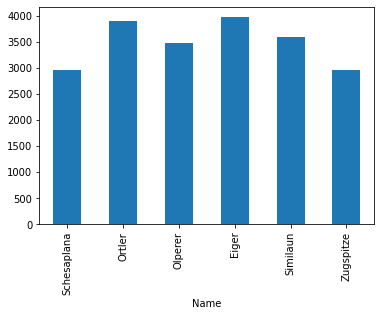

In [32]:
# Hier wird die Höhe der Berge angezeigt
df.Höhe.plot.bar()

### 4.1 Konvertieren, abspeichern und importieren der Daten

Falls notwendig kann der gesamte DataFrame in einen numpy-Array konvertiert werden. Indizes und Labels fallen hierbei weg.

In [33]:
print(df.to_numpy())

[[2965 'Rätikon' 'Österreich/Schweiz' 30.25]
 [3905 'Ortler-Alpen' 'Italien' 49.0]
 [3476 'Zillertaler Alpen' 'Österreich' 11.4]
 [3967 'Berner Alpen' 'Schweiz' 2.21]
 [3599 'Ötztaler Alpen' 'Österreich' 2.8]
 [2962 'Wettersteingebirge' 'Deuschland/Österreich' 25.8]]


Die Daten lassen sich auch im .csv-Format abspeichern. Dieses wird häufig für tabellarische Daten verwendet.

In [34]:
df.to_csv('mountains.csv', sep=',')

Umgekehrt lassen sich Daten auch aus dem .csv-Format importieren.

In [35]:
df_imported = pd.read_csv("mountains.csv", sep=',')
#print(df_imported)
df_imported

,Name,Höhe,Gebirge,Land,Dominanz
0,Schesaplana,2965,Rätikon,Österreich/Schweiz,30.25
1,Ortler,3905,Ortler-Alpen,Italien,49.00
2,Olperer,3476,Zillertaler Alpen,Österreich,11.40
3,Eiger,3967,Berner Alpen,Schweiz,2.21
4,Similaun,3599,Ötztaler Alpen,Österreich,2.80
5,Zugspitze,2962,Wettersteingebirge,Deuschland/Österreich,25.80


In [36]:
df_imported=df_imported.set_index('Name')
df

,Höhe,Gebirge,Land,Dominanz
Name,,,,
Schesaplana,2965,Rätikon,Österreich/Schweiz,30.25
Ortler,3905,Ortler-Alpen,Italien,49.00
Olperer,3476,Zillertaler Alpen,Österreich,11.40
Eiger,3967,Berner Alpen,Schweiz,2.21
Similaun,3599,Ötztaler Alpen,Österreich,2.80
Zugspitze,2962,Wettersteingebirge,Deuschland/Österreich,25.80


# 5. Beispiel

Hier wird eine Patientendatenbank erstellt. Diese enthält Informationen über den Patienten.

In [37]:
# Hier wird die Datenbank erstellt
patient_data = pd.DataFrame({
    'Patienten_ID': [101, 102, 103, 104, 105],
    'Name': ['John', 'Alice', 'Bob', 'Eve', 'Charlie'],
    'Age': [35, 28, 45, 50, 42],
    'Gender': ['männlich', 'weiblich', 'männlich', 'weiblich', 'männlich'],
    'Blood_Type': ['A', '0', 'B', 'AB', 'A']
})

# Hier wird die Patient_ID als Schlüssel festgelegt
patient_data.set_index('Patienten_ID')
patient_data

,Patienten_ID,Name,Age,Gender,Blood_Type
0,101,John,35,männlich,A
1,102,Alice,28,weiblich,0
2,103,Bob,45,männlich,B
3,104,Eve,50,weiblich,AB
4,105,Charlie,42,männlich,A


In einem Folgeschritt werden Untersuchungsdaten aufgenommen und abgespeichert.

In [38]:
test_results = pd.DataFrame({
    'Patienten_ID': [101, 102, 103, 104, 105],
    'Cholesterin': [180, 200, 220, 190, 210],
    'Blutdruck': [120, 130, 140, 135, 125],
    'Temperatur': [37.0, 36.7, 37.1, 37.8, 36.9]
})
patient_data.set_index('Patienten_ID')
test_results

,Patienten_ID,Cholesterin,Blutdruck,Temperatur
0,101,180,120,37.0
1,102,200,130,36.7
2,103,220,140,37.1
3,104,190,135,37.8
4,105,210,125,36.9


Nun sollen die Untersuchungsdaten in die ursprüngliche Datenbank eingefügt werden.

In [39]:
# Hier werden die Daten zusammengefügt
medical_data = pd.merge(patient_data, test_results, on='Patienten_ID')

medical_data

,Patienten_ID,Name,Age,Gender,Blood_Type,Cholesterin,Blutdruck,Temperatur
0,101,John,35,männlich,A,180,120,37.0
1,102,Alice,28,weiblich,0,200,130,36.7
2,103,Bob,45,männlich,B,220,140,37.1
3,104,Eve,50,weiblich,AB,190,135,37.8
4,105,Charlie,42,männlich,A,210,125,36.9


Nun wird ein Blutspender für einen Patienten mit Typ A gesucht. 

In [40]:
# Hier werden die Einträge mit entsprechenden Blutgruppen ausgewählt
medical_data[medical_data.Blood_Type.isin(['A','0'])]

,Patienten_ID,Name,Age,Gender,Blood_Type,Cholesterin,Blutdruck,Temperatur
0,101,John,35,männlich,A,180,120,37.0
1,102,Alice,28,weiblich,0,200,130,36.7
4,105,Charlie,42,männlich,A,210,125,36.9


### Aufgaben

Im folgenden Code wird eine Patientendatenbank mit 1000 Beispielpatienten simuliert

In [41]:
num_entries = 1000

patient_data = pd.DataFrame({
    'Patienten_ID': range(1, num_entries + 1),
    'Name': ['Patient{}'.format(i) for i in range(1, num_entries + 1)],
    'Alter': np.random.randint(0, 100, size=num_entries),
    'Geschlecht': np.random.choice(['weiblich', 'männlich'], size=num_entries),
    'Stadt': np.random.choice(['Innsbruck', 'Wien', 'München', 'Bozen', 'Salzburg'], size=num_entries),
    'Blutdruck': np.random.normal(130, 20, size=num_entries)
})
print(patient_data.head())

   Patienten_ID      Name  Alter Geschlecht      Stadt   Blutdruck
0             1  Patient1     40   weiblich  Innsbruck   99.441883
1             2  Patient2     81   männlich       Wien  126.164352
2             3  Patient3     79   weiblich    München  104.653993
3             4  Patient4     90   weiblich    München  152.716102
4             5  Patient5     98   männlich   Salzburg  133.352347


Erweitern Sie die Datenbank um 2 weitere simulierte Einträge.

In [41]:
# Code hier

Wie viele der Patienten kommen aus Innsbruck?\
Wie viel Prozent sind weiblich bzw. männlich?

In [42]:
# Code hier

Zeigen Sie eine Liste der Patienten älter als 80.

In [43]:
# Code hier

Wie viel Prozent der Patienten über 80 haben Hypertonie, d.h. einen Blutdruck höher als 140 mmHg?

In [44]:
# Code hier